# 재무 특성을 이용한 기업 부실 예측 (이진 분류)

**과목:** 데이터마이닝과 분석 텀프로젝트  
**주제:** 재무 데이터를 활용한 기업 부실(Bankruptcy) 예측 — 불균형 데이터 분류  
**사용 알고리즘:** DecisionTree / RandomForest / ExtraTrees / GradientBoosting  
**평가 지표:** M-Score = (Accuracy + Recall + Precision) / 3  

---

## ⚠️ 데이터 안내

이 노트북은 수업에서 제공받은 비공개 데이터(`classification_train_public.csv`, `classification_test_private.csv`, `classification_description_v2.md`)를 사용합니다.  
저작권 및 수업 규정상 데이터 파일은 이 레포지토리에 포함되지 않습니다.  
동일 데이터를 보유한 경우 아래 **경로 설정 셀**에서 경로만 변경하면 전체 파이프라인이 재현됩니다.

---

## 📋 전체 분석 흐름

```
0. 환경 설정 & 경로 지정
1. Winsorization 함수 정의
2. 데이터 로드 → Train/Validation Split → 0→NaN 처리
3. 전처리(Imputer → Winsorize → Scale → SMOTE) + 4개 모델 1차 비교
4. 하이퍼파라미터 튜닝 (ET·RF: GridSearchCV / GB: RandomizedSearchCV)
5. Feature Importance 기반 Top-70 변수 선택
6. SelectFromModel 2차 변수 선택 + Validation 최종 평가
7. 전체 Train 재학습 → model.pkl 저장
```


---
## ⚙️ 0. 환경 설정
### 0-1. 한글 폰트 설치 (Google Colab 전용)

In [17]:
!apt -qq -y install fonts-nanum > /dev/null

### 0-2. 라이브러리 임포트

In [18]:
import os, shutil, re
from io import StringIO

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.feature_selection import SelectFromModel

from imblearn.over_sampling import SMOTE

import joblib
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")


scikit-learn version: 1.6.1


### 0-3. 한글 폰트 설정

In [19]:
shutil.rmtree(os.path.expanduser("~/.cache/matplotlib"), ignore_errors=True)
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
mpl.rc("font", family="NanumGothic")
mpl.rcParams["axes.unicode_minus"] = False
sns.set_theme(rc={"font.family": "NanumGothic", "axes.unicode_minus": False})
print("한글 폰트 설정 완료")


한글 폰트 설정 완료


### 0-4. 📂 경로 설정 (여기서만 수정)

> 데이터 파일 경로를 실제 환경에 맞게 수정하세요.  
> Google Colab: Google Drive 마운트 후 경로 지정  
> 로컬: 절대 경로 또는 상대 경로 사용


In [20]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# ──────────────────────────────────────────────────
# 경로를 이 셀에서만 관리합니다.
# ──────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/corporate_bankruptcy_prediction_PJ/"
TRAIN_CSV = os.path.join(DATA_DIR, "classification_train_public.csv")
TEST_CSV  = os.path.join(DATA_DIR, "classification_test_private.csv")
DESC_MD   = os.path.join(DATA_DIR, "classification_description_v2.md")
MODEL_OUT = "/content/drive/MyDrive/corporate_bankruptcy_prediction_PJ/bankruptcy_prediction.pkl"

print(f"Train : {TRAIN_CSV}")
print(f"Test  : {TEST_CSV}")
print(f"Desc  : {DESC_MD}")
print(f"Model : {MODEL_OUT}")


Train : /content/drive/MyDrive/corporate_bankruptcy_prediction_PJ/classification_train_public.csv
Test  : /content/drive/MyDrive/corporate_bankruptcy_prediction_PJ/classification_test_private.csv
Desc  : /content/drive/MyDrive/corporate_bankruptcy_prediction_PJ/classification_description_v2.md
Model : /content/drive/MyDrive/corporate_bankruptcy_prediction_PJ/bankruptcy_prediction.pkl


---
## 📌 1. Winsorization 함수 정의

이상치를 **제거하지 않고** 분위수 범위로 압축(clip)하는 함수입니다.

- `winsor_fit` : 학습 데이터로 1% / 99% 분위수를 계산
- `winsor_transform` : 계산된 분위수로 값을 clip

> **Train/Validation 분리 후** `fit`은 train에만, `transform`은 양쪽에 적용해  
> 데이터 누수(data leakage)를 방지합니다.


In [22]:
def winsor_fit(X, lower=0.01, upper=0.99):
    """Train 데이터로 분위수 경계값을 계산합니다."""
    X = np.asarray(X, dtype=float)
    q_low  = np.quantile(X, lower, axis=0)
    q_high = np.quantile(X, upper, axis=0)
    return q_low, q_high

def winsor_transform(X, q_low, q_high):
    """계산된 경계값으로 이상치를 압축합니다."""
    X = np.asarray(X, dtype=float)
    return np.clip(X, q_low, q_high)

print("Winsorization 함수 정의 완료")


Winsorization 함수 정의 완료


---
## 📌 2. 데이터 로드 + Train/Validation Split + 0→NaN 처리

### 처리 순서
1. CSV 로드 및 컬럼명 공백 제거
2. 타겟(`Bankrupt?`) 분리
3. Stratified 8:2 Split → 클래스 비율 유지
4. 0 값이 60% 이상인 컬럼 → NaN 처리 (이후 Imputer에서 median으로 채움)

### 왜 0→NaN인가?
재무 데이터에서 0은 실제 값이 0이 아닌 **결측 또는 미기재**를 나타내는 경우가 많습니다.  
특히 60% 이상이 0인 컬럼은 구조적 결측으로 판단해 Imputer로 처리합니다.

### (1) Stratified Split


In [23]:
TARGET_COL = "Bankrupt?"

df = pd.read_csv(TRAIN_CSV)
df.columns = df.columns.str.strip()

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"전체 데이터: {df.shape}")
print(f"Train: {X_train.shape} | Validation: {X_val.shape}")
print(f"\n클래스 비율 (전체):\n{y.value_counts(normalize=True).round(4)}")


전체 데이터: (5114, 96)
Train: (4091, 95) | Validation: (1023, 95)

클래스 비율 (전체):
Bankrupt?
0    0.9677
1    0.0323
Name: proportion, dtype: float64


### (2) 0값 비율이 60% 이상인 컬럼 → NaN 처리

In [24]:
SUSPECT_THRESH = 0.60
zero_ratio = (X_train == 0).mean().sort_values(ascending=False)
suspect_cols = zero_ratio[zero_ratio >= SUSPECT_THRESH].index.tolist()

X_train_processed = X_train.copy()
X_val_processed   = X_val.copy()

for c in suspect_cols:
    X_train_processed[c] = X_train_processed[c].replace(0, np.nan)
    X_val_processed[c]   = X_val_processed[c].replace(0, np.nan)

print(f"0→NaN 처리 대상 컬럼 수: {len(suspect_cols)}")
print(f"컬럼명: {suspect_cols}")


0→NaN 처리 대상 컬럼 수: 1
컬럼명: ['Liability-Assets Flag']


---
## 📌 3. 전처리 + SMOTE + 기본 모델 비교

전처리를 단계적으로 직접 수행해 **Pipeline 없이도 데이터 누수를 방지**합니다.

### 전처리 순서 및 이유

| 순서 | 단계 | 이유 |
|------|------|------|
| ① | Imputer (median) | NaN이 있으면 Winsorization·Scaler 계산 불가, SMOTE 처리 불가 |
| ② | Winsorization | 이상치 포함 상태로 스케일링하면 정규화가 왜곡됨 |
| ③ | StandardScaler | 스케일 통일 — 거리 기반 연산(SMOTE)에 필요 |
| ④ | SMOTE | 정제된 분포에서 synthetic 샘플을 생성해야 품질이 보장됨 |

> **핵심 원칙:** `fit`은 항상 train 데이터로만, `transform`은 train·val 양쪽에 적용


### 모델 정의 (4종)

In [25]:
# ── DT는 1차 비교 후 성능 열위로 판단 시 튜닝에서 제외됩니다 ──
models = {
    "DT": DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_leaf=5),
    "RF": RandomForestClassifier(random_state=42, n_estimators=200, max_depth=15,
                                 min_samples_leaf=3, n_jobs=-1),
    "ET": ExtraTreesClassifier(random_state=42, n_estimators=200, max_depth=15,
                               min_samples_leaf=5, n_jobs=-1),
    "GB": GradientBoostingClassifier(random_state=42, n_estimators=150,
                                     learning_rate=0.1, max_depth=3),
}
print("모델 4종 정의 완료:", list(models.keys()))


모델 4종 정의 완료: ['DT', 'RF', 'ET', 'GB']


### (1) Imputer — 결측치를 중앙값으로 채움

In [26]:
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_processed)  # train: fit + transform
X_val_imp   = imputer.transform(X_val_processed)        # val: transform만

X_train_imp_df = pd.DataFrame(X_train_imp, columns=X_train_processed.columns)

# 적용 전/후 확인
col_check = "Liability-Assets Flag"
print("[Imputer 전/후 — Liability-Assets Flag]")
print("Before NaN count:", X_train_processed[col_check].isna().sum())
print("After  NaN count:", X_train_imp_df[col_check].isna().sum())
print("\nBefore describe:\n", X_train_processed[col_check].describe())
print("\nAfter  describe:\n", X_train_imp_df[col_check].describe())


[Imputer 전/후 — Liability-Assets Flag]
Before NaN count: 4087
After  NaN count: 0

Before describe:
 count    4.0
mean     1.0
std      0.0
min      1.0
25%      1.0
50%      1.0
75%      1.0
max      1.0
Name: Liability-Assets Flag, dtype: float64

After  describe:
 count    4091.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: Liability-Assets Flag, dtype: float64


### (2) Winsorization — 이상치를 1%~99% 범위로 압축

In [27]:
q_low, q_high = winsor_fit(X_train_imp, lower=0.01, upper=0.99)
X_train_win = winsor_transform(X_train_imp, q_low, q_high)
X_val_win   = winsor_transform(X_val_imp,  q_low, q_high)

X_train_win_df = pd.DataFrame(X_train_win, columns=X_train_processed.columns)

# 결과 확인
col_w = "Borrowing dependency"
print("[Winsorization 전/후 — Borrowing dependency]")
print(f"Before: min={X_train_imp_df[col_w].min():.4f}, max={X_train_imp_df[col_w].max():.4f}")
print(f"After : min={X_train_win_df[col_w].min():.4f}, max={X_train_win_df[col_w].max():.4f}")


[Winsorization 전/후 — Borrowing dependency]
Before: min=0.1871, max=0.8874
After : min=0.3696, max=0.4001


### (3) StandardScaler — 평균 0, 표준편차 1로 정규화

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_win)  # train: fit + transform
X_val_scaled   = scaler.transform(X_val_win)        # val: transform만

# 결과 확인
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_processed.columns)
print("[StandardScaler 적용 후 — mean≈0, std≈1 확인]")
print(X_train_scaled_df[["Liability-Assets Flag",
                          "Net Income to Stockholder's Equity"]].describe().round(4))


[StandardScaler 적용 후 — mean≈0, std≈1 확인]
       Liability-Assets Flag  Net Income to Stockholder's Equity
count                 4091.0                           4091.0000
mean                     0.0                              0.0000
std                      0.0                              1.0001
min                      0.0                             -4.8069
25%                      0.0                             -0.2385
50%                      0.0                              0.1239
75%                      0.0                              0.5375
max                      0.0                              1.9500


### (4) SMOTE — 클래스 불균형 개선

> **SMOTE는 train에만 적용합니다.** Validation은 실제 데이터 분포를 그대로 유지해야  
> 모델 성능을 올바르게 측정할 수 있습니다.

- `sampling_strategy=0.3`: 부실 기업 비율을 정상 기업의 30% 수준으로 조정
- 적용 전 약 3%, 적용 후 약 23%로 개선


In [29]:
smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("[SMOTE 적용 전 클래스 분포]")
print(y_train.value_counts(normalize=True).round(4))
print("\n[SMOTE 적용 후 클래스 분포]")
print(y_train_res.value_counts(normalize=True).round(4))


[SMOTE 적용 전 클래스 분포]
Bankrupt?
0    0.9677
1    0.0323
Name: proportion, dtype: float64

[SMOTE 적용 후 클래스 분포]
Bankrupt?
0    0.7693
1    0.2307
Name: proportion, dtype: float64


### (5) 기본 모델 4종 비교

- **모델 복사** (`base_clf.__class__(**base_clf.get_params())`): 각 모델을 독립적으로 학습하기 위함  
  scikit-learn은 `fit()` 후 내부 파라미터가 갱신되므로 반드시 새 객체를 생성해야 합니다.
- **Validation에는 SMOTE 비적용**: 원본 분포로 공정하게 성능을 측정합니다.
- **threshold=0.5** 고정 (과제 조건)


In [30]:
results = []

for name, base_clf in models.items():
    clf = base_clf.__class__(**base_clf.get_params())   # 독립 객체 생성
    clf.fit(X_train_res, y_train_res)                   # SMOTE 적용 train으로 학습

    y_pred = clf.predict(X_val_scaled)                  # threshold=0.5 (predict 기본값)

    acc  = accuracy_score(y_val, y_pred)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    prec = precision_score(y_val, y_pred, zero_division=0)
    m    = (acc + rec + prec) / 3.0

    results.append({"Model": name, "Accuracy": acc, "Recall": rec,
                    "Precision": prec, "M_Score": m})
    print(f"[{name}] Acc={acc:.4f}  Rec={rec:.4f}  Prec={prec:.4f}  M={m:.4f}")

results_df = pd.DataFrame(results).sort_values(by="M_Score", ascending=False)
print("\n--- 1차 기본 모델 성능 비교 ---")
print(results_df.round(4).to_string(index=False))

best_model_name_initial = results_df.iloc[0]["Model"]
print(f"\n▶ 1차 잠정 최적 모델: {best_model_name_initial}")
print("  → DT는 Tree 계열 중 단일 트리로 일반화 성능이 낮아 4단계 튜닝 대상에서 제외합니다.")


[DT] Acc=0.9306  Rec=0.3636  Prec=0.1935  M=0.4959
[RF] Acc=0.9629  Rec=0.4848  Prec=0.4324  M=0.6267
[ET] Acc=0.9629  Rec=0.6061  Prec=0.4444  M=0.6711
[GB] Acc=0.9638  Rec=0.4848  Prec=0.4444  M=0.6310

--- 1차 기본 모델 성능 비교 ---
Model  Accuracy  Recall  Precision  M_Score
   ET    0.9629  0.6061     0.4444   0.6711
   GB    0.9638  0.4848     0.4444   0.6310
   RF    0.9629  0.4848     0.4324   0.6267
   DT    0.9306  0.3636     0.1935   0.4959

▶ 1차 잠정 최적 모델: ET
  → DT는 Tree 계열 중 단일 트리로 일반화 성능이 낮아 4단계 튜닝 대상에서 제외합니다.


---
## 📌 4. 하이퍼파라미터 튜닝 (ET · RF · GB)

- **ET, RF**: `GridSearchCV` — 파라미터 공간이 제한적이므로 전수 탐색
- **GB**: `RandomizedSearchCV` — 파라미터 조합이 많아 랜덤 샘플링으로 효율화

| 모델 | 탐색 방법 | 이유 |
|------|-----------|------|
| ET, RF | GridSearchCV | 조합 수 36개로 전수 탐색 비용이 허용 범위 |
| GB | RandomizedSearchCV (n_iter=10) | 조합 수 36개지만 학습 비용이 크므로 무작위 10회 |

`scoring="f1"` — 불균형 데이터에서 recall·precision 균형을 반영하는 지표  
`cv=3` — 3-fold 교차검증으로 일반화 성능 추정


In [31]:
print("--- 4단계: 하이퍼파라미터 튜닝 시작 ---")

tuned_models = {
    "ET": {
        "model": ExtraTreesClassifier(random_state=42, n_jobs=-1),
        "searcher": GridSearchCV,
        "grid": {
            "n_estimators":    [200, 300, 400],
            "max_depth":       [15, 20, 25, 30],
            "min_samples_leaf":[3, 5, 8],
        },
    },
    "RF": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "searcher": GridSearchCV,
        "grid": {
            "n_estimators":    [200, 300, 400],
            "max_depth":       [15, 20, 25, 30],
            "min_samples_leaf":[3, 5, 8],
        },
    },
    "GB": {
        "model": GradientBoostingClassifier(random_state=42),
        "searcher": RandomizedSearchCV,
        "grid": {
            "n_estimators":    [100, 150, 200],
            "learning_rate":   [0.05, 0.1, 0.15],
            "max_depth":       [3, 4, 5],
            "min_samples_leaf":[3, 5],
        },
        "n_iter": 10,
    },
}


--- 4단계: 하이퍼파라미터 튜닝 시작 ---


In [32]:
tuned_results      = []
best_m_score_global = -1   # M-Score는 0~1 범위이므로 -1로 초기화하면 첫 모델부터 갱신됨
best_model_name     = None
best_clf            = None

for name, item in tuned_models.items():
    model      = item["model"]
    Searcher   = item["searcher"]
    param_grid = item["grid"]

    if Searcher == RandomizedSearchCV:
        search = Searcher(
            estimator=model,
            param_distributions=param_grid,
            n_iter=item.get("n_iter", 10),
            scoring="f1",
            cv=3,
            n_jobs=-1,
            verbose=0,          # 0: 로그 없음 / 1: 간단 / 2: 상세
            random_state=42,
        )
    else:
        search = Searcher(
            estimator=model,
            param_grid=param_grid,
            scoring="f1",
            cv=3,
            n_jobs=-1,
            verbose=0,
        )

    search.fit(X_train_res, y_train_res)
    best_est = search.best_estimator_
    y_pred   = best_est.predict(X_val_scaled)

    acc  = accuracy_score(y_val, y_pred)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    prec = precision_score(y_val, y_pred, zero_division=0)
    m    = (acc + rec + prec) / 3.0

    tuned_results.append({
        "Model": name,
        "Searcher": "Grid" if Searcher == GridSearchCV else "Randomized",
        "Accuracy": acc, "Recall": rec, "Precision": prec, "M_Score": m,
        "Best_Params": search.best_params_,
    })
    print(f"[{name}] M-Score: {m:.4f}  Best: {search.best_params_}")

    if m > best_m_score_global:
        best_m_score_global = m
        best_model_name     = name
        best_clf            = best_est

tuned_df = pd.DataFrame(tuned_results).sort_values(by="M_Score", ascending=False)
print("\n--- 2차 튜닝 결과 ---")
print(tuned_df[["Model","Searcher","Accuracy","Recall","Precision","M_Score"]].round(4).to_string(index=False))
print(f"\n▶ 최종 선택 모델: {best_model_name}  (M-Score: {best_m_score_global:.4f})")

final_best_classifier = best_clf
base_clf_class  = final_best_classifier.__class__
base_clf_params = final_best_classifier.get_params()


[ET] M-Score: 0.6511  Best: {'max_depth': 20, 'min_samples_leaf': 3, 'n_estimators': 200}
[RF] M-Score: 0.6153  Best: {'max_depth': 20, 'min_samples_leaf': 3, 'n_estimators': 300}
[GB] M-Score: 0.6408  Best: {'n_estimators': 150, 'min_samples_leaf': 3, 'max_depth': 5, 'learning_rate': 0.15}

--- 2차 튜닝 결과 ---
Model   Searcher  Accuracy  Recall  Precision  M_Score
   ET       Grid    0.9658  0.5152     0.4722   0.6511
   GB Randomized    0.9677  0.4545     0.5000   0.6408
   RF       Grid    0.9629  0.4545     0.4286   0.6153

▶ 최종 선택 모델: ET  (M-Score: 0.6511)


---
## 📌 5. Feature Importance 기반 변수 선택 (Top 70)

4단계에서 선택된 최적 모델의 `feature_importances_`로 변수 중요도를 계산합니다.

> **참고:** 이 중요도는 전체 train(80%)에서 학습한 모델 기준입니다.  
> 이후 6단계에서 SelectFromModel로 2차 필터링을 거쳐 최종 변수 집합을 확정합니다.


In [33]:
importance_df = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": final_best_classifier.feature_importances_,
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

selected_features = importance_df.head(70)["Feature"].tolist()

print(f"전체 변수: {len(X.columns)}개  →  Top-70 선택")
print("\n[Top 10 변수 중요도]")
print(importance_df.head(10).to_string(index=False, float_format="%.4f"))


전체 변수: 95개  →  Top-70 선택

[Top 10 변수 중요도]
                                                Feature  Importance
                                   Borrowing dependency      0.0512
                                    Liability to Equity      0.0396
                     Net Income to Stockholder's Equity      0.0380
                                       Net worth/Assets      0.0379
                             Total debt/Total net worth      0.0331
                                           Debt ratio %      0.0309
      ROA(B) before interest and depreciation after tax      0.0306
                             Net Income to Total Assets      0.0274
ROA(C) before interest and depreciation before interest      0.0272
                            Current Liability to Equity      0.0252


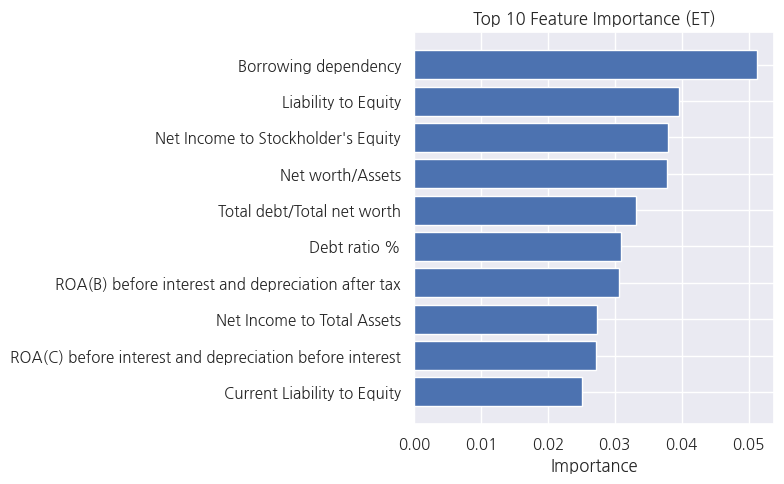

In [34]:
# Top-10 변수 중요도 시각화
top10 = importance_df.head(10)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10["Feature"], top10["Importance"])
ax.invert_yaxis()
ax.set_title(f"Top 10 Feature Importance ({best_model_name})")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


---
## 📌 6. SelectFromModel 2차 변수 선택 + Validation 최종 평가

### Top-K 단독 vs SelectFromModel 병합 이유

| 방법 | 특징 |
|------|------|
| Top-K (5단계) | 단순 중요도 순위 기준, 연관된 변수가 중복 포함될 수 있음 |
| SelectFromModel (6단계) | 모델이 스스로 최선의 조합을 선택 → 차원 축소 + 과적합 방지 |

두 단계를 순서대로 적용하면 **중요 변수 풀에서 모델이 최적 조합을 재선택**합니다.

### 6단계 Validation에서 SMOTE를 적용하지 않는 이유

Validation은 **실제 테스트 환경을 시뮬레이션**하는 단계입니다.  
실제 운영 데이터는 불균형 그대로 들어오므로, Validation도 원본 분포로 평가해야  
실제 성능을 올바르게 측정할 수 있습니다.


### (1) Top-70 변수 기준으로 전처리 재수행

In [35]:
# Top-70 변수만 선택
X_train_sel = X_train_processed[selected_features]
X_val_sel   = X_val_processed[selected_features]

# Imputer
imputer_fs     = SimpleImputer(strategy="median")
X_train_imp_fs = imputer_fs.fit_transform(X_train_sel)
X_val_imp_fs   = imputer_fs.transform(X_val_sel)

# Winsorization
q_low_fs, q_high_fs = winsor_fit(X_train_imp_fs, lower=0.01, upper=0.99)
X_train_win_fs = winsor_transform(X_train_imp_fs, q_low_fs, q_high_fs)
X_val_win_fs   = winsor_transform(X_val_imp_fs,   q_low_fs, q_high_fs)

# StandardScaler
scaler_fs         = StandardScaler()
X_train_scaled_fs = scaler_fs.fit_transform(X_train_win_fs)
X_val_scaled_fs   = scaler_fs.transform(X_val_win_fs)

print(f"Top-70 전처리 완료 | train: {X_train_scaled_fs.shape}, val: {X_val_scaled_fs.shape}")


Top-70 전처리 완료 | train: (4091, 70), val: (1023, 70)


### (2) SelectFromModel — threshold=median으로 2차 변수 선택

In [36]:
selector = SelectFromModel(
    base_clf_class(**base_clf_params),
    threshold="median"   # 중요도 중앙값 이상인 변수만 선택
)
selector.fit(X_train_scaled_fs, y_train)   # SMOTE 없이 원본 분포로 fit

selected_after_fs = [
    col for col, keep in zip(selected_features, selector.get_support()) if keep
]

X_train_final = selector.transform(X_train_scaled_fs)
X_val_final   = selector.transform(X_val_scaled_fs)

print(f"Top-70 → SelectFromModel 후 최종 변수: {len(selected_after_fs)}개")
print(f"최종 train shape: {X_train_final.shape}")


Top-70 → SelectFromModel 후 최종 변수: 35개
최종 train shape: (4091, 35)


### (3) 최종 모델 학습 및 Validation 평가

> **SMOTE 미적용 이유:** Validation은 실제 운영 환경(불균형 분포)을 그대로 재현해야 하므로  
> 오버샘플링 없이 원본 y_train으로 학습 후 평가합니다.


In [37]:
# SMOTE 없이 원본 분포(y_train)로 학습 — Validation은 실제 환경을 반영해야 하므로
final_clf_val = base_clf_class(**base_clf_params)
final_clf_val.fit(X_train_final, y_train)

y_val_proba = final_clf_val.predict_proba(X_val_final)[:, 1]
y_val_pred  = (y_val_proba >= 0.5).astype(int)   # threshold=0.5 고정

acc_v  = accuracy_score(y_val, y_val_pred)
rec_v  = recall_score(y_val,   y_val_pred, zero_division=0)
prec_v = precision_score(y_val, y_val_pred, zero_division=0)
m_v    = (acc_v + rec_v + prec_v) / 3.0

print("[Validation 성능 — 최종 변수 선택 후]")
print(f"Accuracy : {acc_v:.4f}")
print(f"Recall   : {rec_v:.4f}")
print(f"Precision: {prec_v:.4f}")
print(f"M-Score  : {m_v:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=["정상(0)", "부실(1)"]))


[Validation 성능 — 최종 변수 선택 후]
Accuracy : 0.9717
Recall   : 0.1212
Precision: 1.0000
M-Score  : 0.6976

Classification Report:
              precision    recall  f1-score   support

       정상(0)       0.97      1.00      0.99       990
       부실(1)       1.00      0.12      0.22        33

    accuracy                           0.97      1023
   macro avg       0.99      0.56      0.60      1023
weighted avg       0.97      0.97      0.96      1023



### (4) Confusion Matrix

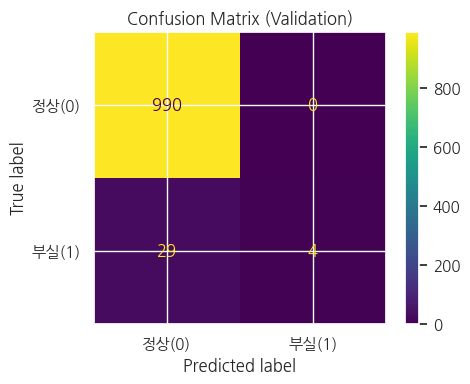

In [38]:
cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["정상(0)", "부실(1)"]).plot(
    values_format="d", ax=ax)
ax.set_title("Confusion Matrix (Validation)")
plt.tight_layout()
plt.show()


### (5) Precision-Recall Curve

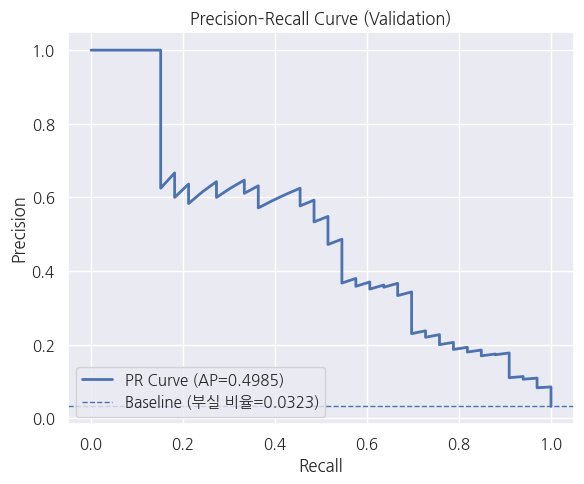

In [39]:
prec_arr, rec_arr, _ = precision_recall_curve(y_val, y_val_proba)
avg_prec = average_precision_score(y_val, y_val_proba)
baseline = y_val.mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec_arr, prec_arr, lw=2, label=f"PR Curve (AP={avg_prec:.4f})")
ax.axhline(baseline, linestyle="--", lw=1,
           label=f"Baseline (부실 비율={baseline:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curve (Validation)")
ax.legend(loc="lower left")
ax.grid(True)
plt.tight_layout()
plt.show()


---
## 📌 7. 전체 Train 재학습 → model.pkl 저장

Validation 단계까지 확정된 파이프라인을 **전체 Train 데이터**에 다시 적용합니다.  
최종 모델은 `model.pkl`로 저장되며, `sklearn.__version__`도 함께 출력합니다.

### 왜 전체 데이터로 재학습하는가?
- Validation 분할 시 20%를 학습에서 제외했으므로, 최종 모델은 전체 데이터로  
  학습해 일반화 성능을 최대화합니다.
- Test set은 교수 측에서 동일 조건(`random_state=42`, `threshold=0.5`)으로 평가합니다.

> ⚠️ **재현성 안내**  
> 저장된 `model.pkl`은 sklearn **{sklearn.__version__}** 환경에서 생성되었습니다.  
> 다른 버전에서 로드 시 경고가 발생할 수 있으므로 `requirements.txt`의 버전을 맞춰주세요.


In [40]:
print("=== 7단계: 전체 Train 재학습 및 최종 파일 저장 ===")

# (1) 전체 train 데이터 준비
X_all = df.drop(columns=[TARGET_COL])
y_all = df[TARGET_COL]

X_all_processed = X_all.copy()
for c in suspect_cols:
    X_all_processed[c] = X_all_processed[c].replace(0, np.nan)

print(f"전체 train shape: {X_all_processed.shape}")


=== 7단계: 전체 Train 재학습 및 최종 파일 저장 ===
전체 train shape: (5114, 95)


In [41]:
# (2) private test 로드 + 동일 전처리
test_df = pd.read_csv(TEST_CSV)
test_df.columns = test_df.columns.str.strip()
X_test_all = test_df.copy()

for c in suspect_cols:
    if c in X_test_all.columns:
        X_test_all[c] = X_test_all[c].replace(0, np.nan)

print(f"test shape: {X_test_all.shape}")


test shape: (1705, 95)


In [42]:
# (3) Top-70 변수 선택
X_all_sel  = X_all_processed[selected_features]
X_test_sel = X_test_all[selected_features]

# (4) 전처리: Imputer → Winsorization → StandardScaler
final_imputer = SimpleImputer(strategy="median")
X_all_imp  = final_imputer.fit_transform(X_all_sel)
X_test_imp = final_imputer.transform(X_test_sel)

q_low_f, q_high_f = winsor_fit(X_all_imp, lower=0.01, upper=0.99)
X_all_win  = winsor_transform(X_all_imp,  q_low_f, q_high_f)
X_test_win = winsor_transform(X_test_imp, q_low_f, q_high_f)

final_scaler  = StandardScaler()
X_all_scaled  = final_scaler.fit_transform(X_all_win)
X_test_scaled = final_scaler.transform(X_test_win)

print(f"전처리 후 — train: {X_all_scaled.shape}, test: {X_test_scaled.shape}")


전처리 후 — train: (5114, 70), test: (1705, 70)


In [46]:
# (5) SelectFromModel 2차 변수 선택 (전체 train 기준)
final_selector = SelectFromModel(
    base_clf_class(**base_clf_params),
    threshold="median",
    prefit=False
)
final_selector.fit(X_all_scaled, y_all)

mask_full = final_selector.get_support()
if mask_full.sum() == 0:
    print("[WARN] SelectFromModel 선택 변수 없음 → Top-70 그대로 사용")
    X_all_final  = X_all_scaled
    X_test_final = X_test_scaled
    selected_final = selected_features.copy()
else:
    X_all_final  = final_selector.transform(X_all_scaled)
    X_test_final = final_selector.transform(X_test_scaled)
    selected_final = np.array(selected_features)[mask_full].tolist()

print(f"최종 변수 개수: {len(selected_final)}개")
print(f"최종 train: {X_all_final.shape}, test: {X_test_final.shape}")


최종 변수 개수: 35개
최종 train: (5114, 35), test: (1705, 35)


In [47]:
# Simplified Name 매핑
with open(DESC_MD, "r", encoding="utf-8") as f:
    lines = f.readlines()

table_lines = []
in_table = False
for line in lines:
    if "|" in line and ("Original Variable" in line or in_table):
        in_table = True
        table_lines.append(line)
    elif in_table and ("|" not in line or line.strip() == ""):
        break

table_clean = [
    line for line in table_lines
    if not re.match(r"^\s*\|?\s*-[-\s]*\|", line)
]

table_str = "".join(table_clean)
desc = pd.read_csv(StringIO(table_str), sep="|").dropna(axis=1, how="all")
desc.columns = desc.columns.str.strip()
desc = desc.map(lambda x: x.strip() if isinstance(x, str) else x)

mapping_table = desc[["Original Variable (CSV Header)", "Simplified Name"]]
origin_to_simple = dict(zip(
    mapping_table["Original Variable (CSV Header)"],
    mapping_table["Simplified Name"]
))

final_feature_names = [origin_to_simple[col.strip()] for col in selected_final]
print(f"Simplified Name 매핑 완료: {len(final_feature_names)}개")
print(final_feature_names)

Simplified Name 매핑 완료: 35개
['cost_interest_bearing_debt', 'liability_to_equity', 'net_income_to_equity', 'equity_to_assets', 'total_liability_to_equity', 'liability_to_assets', 'roa_b', 'net_income_to_assets', 'roa_c', 'curr_liability_to_equity', 'curr_liabilities_to_equity', 'eps_net_income', 'retained_earnings_to_assets', 'pretax_income_per_share', 'pretax_income_to_capital', 'bvps_a', 'adj_net_income_to_sales', 'bvps_c', 'equity_to_long_term_liability', 'roa_a', 'curr_liability_to_assets', 'net_non_op_income_ratio', 'curr_liability_to_curr_assets', 'bvps_b', 'working_capital_to_assets', 'interest_expenses_to_revenue', 'net_income_to_sales', 'working_capital_to_equity', 'degree_financial_leverage', 'equity_to_liability', 'pretax_income_to_sales', 'interest_coverage_ratio', 'fixed_asset_turnover', 'days_receivable_outstanding', 'fixed_assets_per_employee']


In [48]:
# (6) 최종 모델 학습
final_model = base_clf_class(**base_clf_params)
final_model.fit(X_all_final, y_all)

# train 전체 성능 (참고용 — 과적합 여부 확인)
y_pred_all = (final_model.predict_proba(X_all_final)[:, 1] >= 0.5).astype(int)
acc_all  = accuracy_score(y_all, y_pred_all)
rec_all  = recall_score(y_all,  y_pred_all, zero_division=0)
prec_all = precision_score(y_all, y_pred_all, zero_division=0)
m_all    = (acc_all + rec_all + prec_all) / 3.0

print("[최종 모델 Train 전체 성능 (참고용)]")
print(f"Accuracy : {acc_all:.4f}")
print(f"Recall   : {rec_all:.4f}")
print(f"Precision: {prec_all:.4f}")
print(f"M-Score  : {m_all:.4f}")
print(f"\n※ Validation M-Score({m_v:.4f})와 비교해 과적합 여부를 확인하세요.")


[최종 모델 Train 전체 성능 (참고용)]
Accuracy : 0.9851
Recall   : 0.5394
Precision: 1.0000
M-Score  : 0.8415

※ Validation M-Score(0.6976)와 비교해 과적합 여부를 확인하세요.


In [49]:
# (7) submission_test.csv 생성
y_test_pred = (final_model.predict_proba(X_test_final)[:, 1] >= 0.5).astype(int)

test_features_df = pd.DataFrame(
    X_test_final,
    columns=final_feature_names,   # ← Simplified Name 적용
    index=test_df.index
)
submission_test = test_features_df.copy()
submission_test["y_pred"] = y_test_pred

submission_test.to_csv(os.path.join(DATA_DIR, "submission_test.csv"), index=False)  # ← Drive 경로
print(f"[저장] submission_test.csv — shape: {submission_test.shape}")

# (8) model.pkl 저장
joblib.dump(final_model, MODEL_OUT)
print(f"[저장] {MODEL_OUT} (scikit-learn {sklearn.__version__})")
print("\n✅ 전체 파이프라인 완료")

[저장] submission_test.csv — shape: (1705, 36)
[저장] /content/drive/MyDrive/corporate_bankruptcy_prediction_PJ/bankruptcy_prediction.pkl (scikit-learn 1.6.1)

✅ 전체 파이프라인 완료


---
## 📎 재현을 위한 환경 정보

아래 셀 출력값을 `requirements.txt`에 반영하면 동일 환경을 재현할 수 있습니다.


In [50]:
import platform, importlib

pkgs = ["numpy", "pandas", "matplotlib", "seaborn",
        "sklearn", "imblearn", "joblib"]

print(f"Python : {platform.python_version()}")
for pkg in pkgs:
    try:
        m = importlib.import_module(pkg)
        ver = getattr(m, "__version__", "?")
    except ImportError:
        ver = "not installed"
    print(f"{pkg:15s}: {ver}")


Python : 3.12.13
numpy          : 2.0.2
pandas         : 2.2.2
matplotlib     : 3.10.0
seaborn        : 0.13.2
sklearn        : 1.6.1
imblearn       : 0.14.1
joblib         : 1.5.3
